In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [5]:
import os

print(os.listdir(path))

['hashes.txt', 'Reviews.csv', 'database.sqlite']


In [3]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "Reviews.csv"))

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
import kagglehub
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# Download NLTK resources (Run only once)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
# Dataset shape
print("Shape:", df.shape)


Shape: (568454, 10)


In [8]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [9]:
# Information about dataset
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [10]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [11]:
# Select required columns
df = df[['Score', 'Text']]

# Remove missing values
df = df.dropna()

# Display first 5 rows
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [12]:
def get_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score <= 2:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Score"].apply(get_sentiment)

df.head()

,Score,Text,Sentiment
0,5,I have bought several of the Vitality canned d...,Positive
1,1,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,This is a confection that has been around a fe...,Positive
3,2,If you are looking for the secret ingredient i...,Negative
4,5,Great taffy at a great price. There was a wid...,Positive


In [13]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [14]:
# Reduce dataset size
df = df.sample(n=20000, random_state=42)

# Keep only required columns
df = df[['Score', 'Text']].dropna()

In [15]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stopwords.words("english")]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words
    return " ".join(words)


In [16]:
df["Clean_Text"] = df["Text"].apply(preprocess)

df[["Text", "Clean_Text"]].head()

,Text,Clean_Text
165256,Having tried a couple of other brands of glute...,tried couple brand glutenfree sandwich cooky b...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever cant find house pop top bo...
427827,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
433954,"First there was Frosted Mini-Wheats, in origin...",first frosted miniwheats original size frosted...
70260,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


In [17]:
from collections import Counter

all_words = " ".join(df["Clean_Text"]).split()

word_count = Counter(all_words)

print(word_count.most_common(20))

[('like', 9311), ('br', 9208), ('taste', 7633), ('good', 6980), ('one', 6718), ('product', 6386), ('flavor', 6370), ('coffee', 6087), ('great', 5791), ('love', 5638), ('food', 5417), ('tea', 5276), ('would', 4414), ('get', 4217), ('dog', 3701), ('make', 3619), ('time', 3559), ('really', 3440), ('dont', 3320), ('much', 3202)]


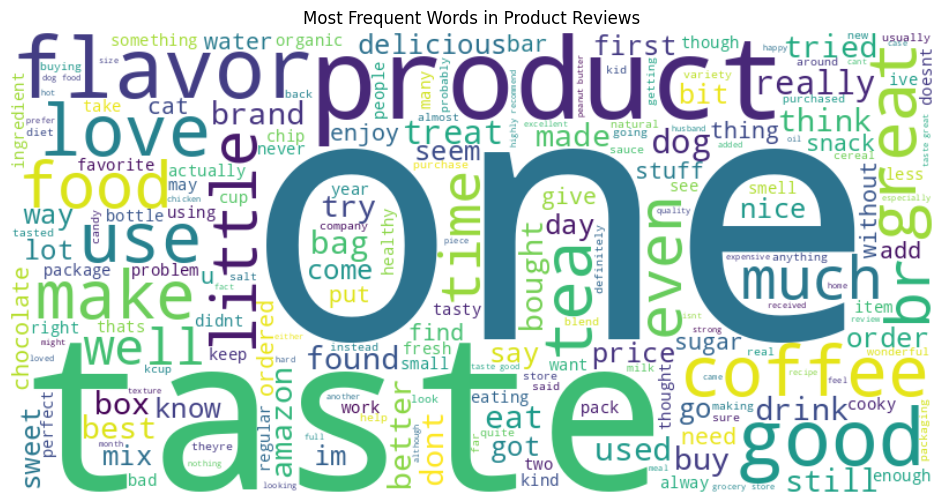

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(df["Clean_Text"]))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Product Reviews")
plt.show()

In [19]:
def get_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score <= 2:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Score"].apply(get_sentiment)

df.head()
print(df["Sentiment"].value_counts())

Sentiment
Positive    15595
Negative     2886
Neutral      1519
Name: count, dtype: int64


In [20]:
# Filter negative reviews
negative_reviews = df[df["Sentiment"] == "Negative"]

print("Number of Negative Reviews:", len(negative_reviews))

negative_reviews.head()

Number of Negative Reviews: 2886


,Score,Text,Clean_Text,Sentiment
433954,2,"First there was Frosted Mini-Wheats, in origin...",first frosted miniwheats original size frosted...,Negative
34321,1,Simply awful. This product should be taken of...,simply awful product taken market immediately ...,Negative
492897,1,It sure would be nice if they stated ANYWHERE ...,sure would nice stated anywhere description co...,Negative
469701,1,"Disappointingly, this is IMITATION Almond Extr...",disappointingly imitation almond extract terri...,Negative
234760,1,I bought this item for my dog to play with. Sh...,bought item dog play smart get food initially ...,Negative


In [21]:
from collections import Counter

negative_words = " ".join(negative_reviews["Clean_Text"]).split()

word_count = Counter(negative_words)

print("Top 20 Words in Negative Reviews")

print(word_count.most_common(20))

Top 20 Words in Negative Reviews
[('like', 1628), ('br', 1448), ('taste', 1378), ('product', 1366), ('would', 1003), ('one', 998), ('food', 890), ('coffee', 861), ('flavor', 856), ('good', 763), ('dog', 657), ('get', 629), ('tea', 612), ('dont', 609), ('even', 562), ('really', 554), ('time', 549), ('bag', 542), ('amazon', 507), ('buy', 501)]


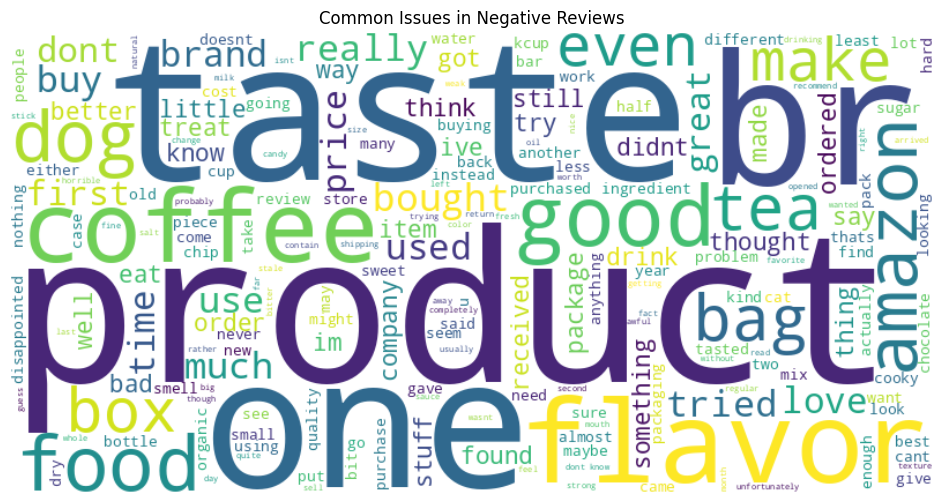

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(negative_reviews["Clean_Text"]))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Issues in Negative Reviews")
plt.show()

In [23]:
sentiment = df["Sentiment"].value_counts()

print(sentiment)

percentage = (sentiment / len(df)) * 100

print("\nPercentage of Each Sentiment")

print(percentage)

Sentiment
Positive    15595
Negative     2886
Neutral      1519
Name: count, dtype: int64

Percentage of Each Sentiment
Sentiment
Positive    77.975
Negative    14.430
Neutral      7.595
Name: count, dtype: float64


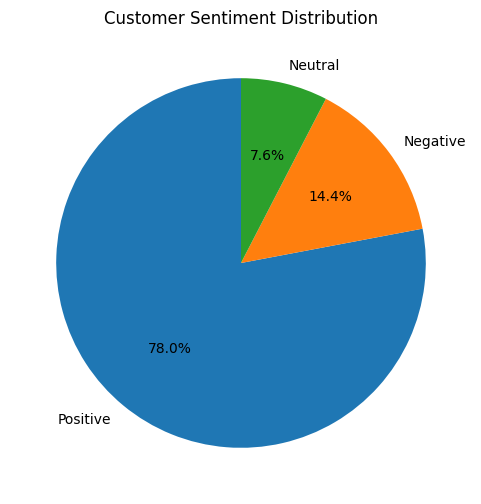

In [24]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment,
    labels=sentiment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Sentiment Distribution")

plt.show()